In [1]:
# Basic imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


plt.rcParams['axes.facecolor'] = 'f8f9fa'


import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score,
    roc_curve, precision_recall_curve
)
import warnings
warnings.filterwarnings('ignore')
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB




# **Customer Churn Prediction**
Goal: Predict which customers will churn (cancel service) and identify customer characteristics associated with attrition.

# **Part A: Data Exploration**

In [3]:
# Load your dataset
data1 = pd.read_csv('/question1_customer_churn.csv')

# Basic exploration
print("Dataset Info:")
print(data1.info())
print("\nDataset Description:")
print(data1.describe())
print("Churn Rate:")
print(data1['churn'].value_counts(normalize=True))



Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 22 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   customer_id        5000 non-null   object 
 1   tenure             5000 non-null   int64  
 2   age                5000 non-null   int64  
 3   gender             5000 non-null   int64  
 4   senior_citizen     5000 non-null   int64  
 5   partner            5000 non-null   int64  
 6   dependents         5000 non-null   int64  
 7   phone_service      5000 non-null   int64  
 8   multiple_lines     5000 non-null   int64  
 9   internet_service   5000 non-null   int64  
 10  online_security    5000 non-null   int64  
 11  online_backup      5000 non-null   int64  
 12  device_protection  5000 non-null   int64  
 13  tech_support       5000 non-null   int64  
 14  streaming_tv       5000 non-null   int64  
 15  streaming_movies   5000 non-null   int64  
 16  contract  

Data is loaded and explored above to view all features, data types, count and to gather basic stats.

Calculate Churn Rate by Contract Type and Internet Service:

In [4]:
print("Churn Rate by Contract Type:")
churn_by_contract = data1.groupby('contract')['churn'].agg(['mean', 'count'])
print(churn_by_contract)

print("Churn Rate by Internet Service:")
churn_by_internet = data1.groupby('internet_service')['churn'].agg(['mean', 'count'])
print(churn_by_contract)

Churn Rate by Contract Type:
              mean  count
contract                 
0         0.452035   2752
1         0.161137   1266
2         0.161914    982
Churn Rate by Internet Service:
              mean  count
contract                 
0         0.452035   2752
1         0.161137   1266
2         0.161914    982


The mean was used to give a percentage rate of churn, which was identified as the target column.

Two Visualizations reflecting Churn Rate:

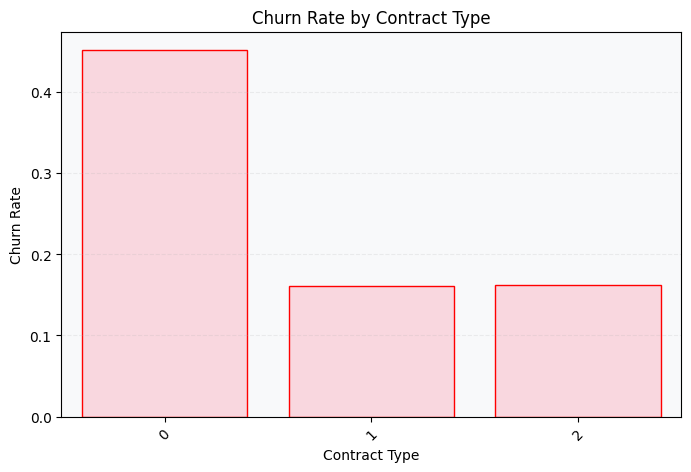

In [ ]:
churn_by_contract = data1.groupby('contract')['churn'].mean().reset_index()

plt.figure(figsize=(8,5))
sns.barplot(
    data=churn_by_contract,
    x='contract',
    y='churn',
    color="#ffd1dc",
    edgecolor='red'
)

plt.title("Churn Rate by Contract Type")
plt.ylabel("Churn Rate")
plt.xlabel("Contract Type")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.2)

plt.show()

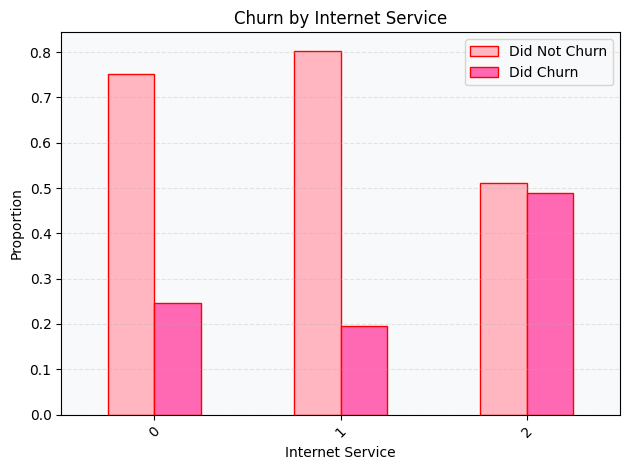

In [ ]:
pd.crosstab(data1["internet_service"], data1["churn"], normalize="index").plot(
    kind="bar",
    color=["#ffb6c1", "#ff69b4"],
    edgecolor='red'
)

plt.title("Churn by Internet Service")
plt.ylabel("Proportion")
plt.xlabel("Internet Service")
plt.xticks(rotation=45)
plt.legend(["Did Not Churn", "Did Churn"])
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

These graphs give a visual explanatin of how many users are likely to churn based off their contract type and internet service.

# **Part B: Model Building**

In [ ]:
# Prepare data for modeling
# Select features and target
features = ['tenure', 'age', 'gender', 'senior_citizen', 'partner', 'dependents', 'phone_service', 'multiple_lines',
            'internet_service', 'online_security','online_backup', 'device_protection', 'tech_support', 'streaming_tv',
            'streaming_movies', 'contract', 'paperless_billing', 'payment_method', 'monthly_charges', 'total_charges']
X = data1[features]
y = data1['churn']

# Convert categorical variables into numeric
X = pd.get_dummies(X, drop_first=True)


# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


print(f"Training set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")
print(f"Feature names: {features}")
print(f"Number of features after encoding: {X.shape[1]}")

Training set size: 3500
Test set size: 1500
Feature names: ['tenure', 'age', 'gender', 'senior_citizen', 'partner', 'dependents', 'phone_service', 'multiple_lines', 'internet_service', 'online_security', 'online_backup', 'device_protection', 'tech_support', 'streaming_tv', 'streaming_movies', 'contract', 'paperless_billing', 'payment_method', 'monthly_charges', 'total_charges']
Number of features after encoding: 20


First the target variable is defined (churn category) then all categorical variables are convered into numeric. The data is then split so the model can be trained. Features are then scaled to be in the same measurements, this is so difference in value measures are not drastic. Then, the training/test size, feature names and number of features are printed to verify accuracy.

**Logistic Model:**

In [ ]:
# Train Logistic Regression model
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train_scaled, y_train)

# Scale the features
lr_model.fit(X_train_scaled, y_train)
y_pred_lr = lr_model.predict(X_test_scaled)

# Make predictions
y_pred_lr = lr_model.predict(X_test_scaled)
y_pred_proba_lr = lr_model.predict_proba(X_test_scaled)[:, 1]

# Evaluate the model
print("Logistic Regression Results:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_lr):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_lr):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_lr):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_lr):.4f}")
print(f"AUC-ROC: {roc_auc_score(y_test, y_pred_proba_lr):.4f}")

Logistic Regression Results:
Accuracy: 0.7313
Precision: 0.6138
Recall: 0.4419
F1-Score: 0.5139
AUC-ROC: 0.7707


This code first trains the model using the scaled data and then predictions are made on the test set. To evaluate the model; accuracy, precision, recall, F!-score and AUC-ROC were used to assess overall performance.

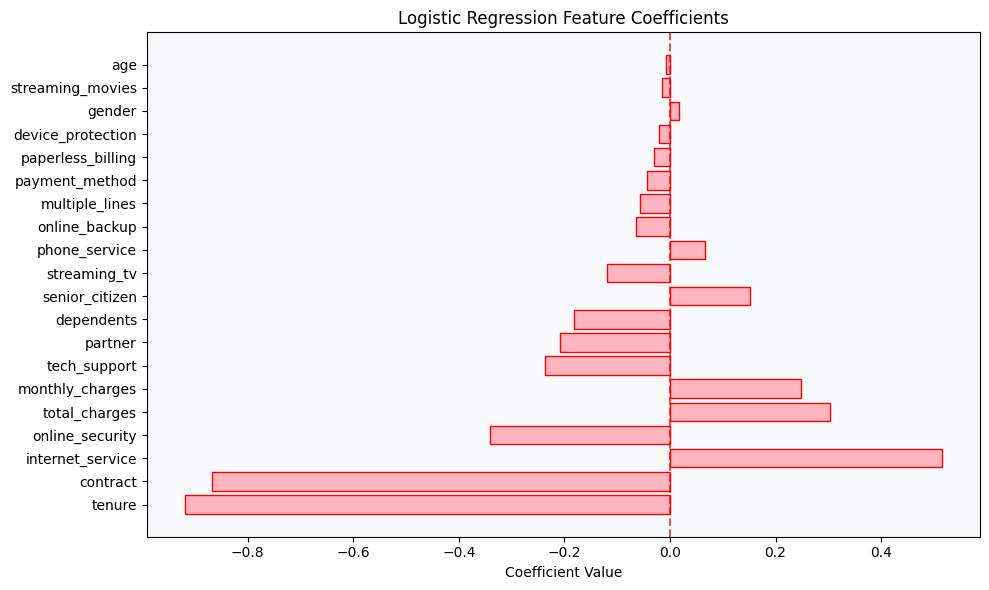

Feature Importance (by absolute coefficient):
              Feature  Coefficient  Abs_Coefficient
0              tenure    -0.919752         0.919752
15           contract    -0.867225         0.867225
8    internet_service     0.515677         0.515677
9     online_security    -0.340467         0.340467
19      total_charges     0.303409         0.303409
18    monthly_charges     0.248482         0.248482
12       tech_support    -0.237308         0.237308
4             partner    -0.208660         0.208660
5          dependents    -0.181165         0.181165
3      senior_citizen     0.150871         0.150871
13       streaming_tv    -0.118785         0.118785
6       phone_service     0.066645         0.066645
10      online_backup    -0.063468         0.063468
7      multiple_lines    -0.056468         0.056468
17     payment_method    -0.043576         0.043576
16  paperless_billing    -0.030386         0.030386
11  device_protection    -0.020506         0.020506
2              gen

In [ ]:
#Analyze feature importance in logistic regression

feature_importance = pd.DataFrame({
    'Feature': features,
    'Coefficient': lr_model.coef_[0],
    'Abs_Coefficient': np.abs(lr_model.coef_[0])
})
feature_importance = feature_importance.sort_values('Abs_Coefficient', ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(feature_importance['Feature'], feature_importance['Coefficient'], color="#ffb6c1", edgecolor="red")
plt.title('Logistic Regression Feature Coefficients')
plt.xlabel('Coefficient Value')
plt.axvline(x=0, color='red', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("Feature Importance (by absolute coefficient):")
print(feature_importance)

The most importance features and coefficients tell us the weight each feature holds on the overall impact of the target variable (churn). The coefficients with the greatest impact are tenure, contract tpye, internet service and online security.

**K-Nearest Neighbors (KNN):**

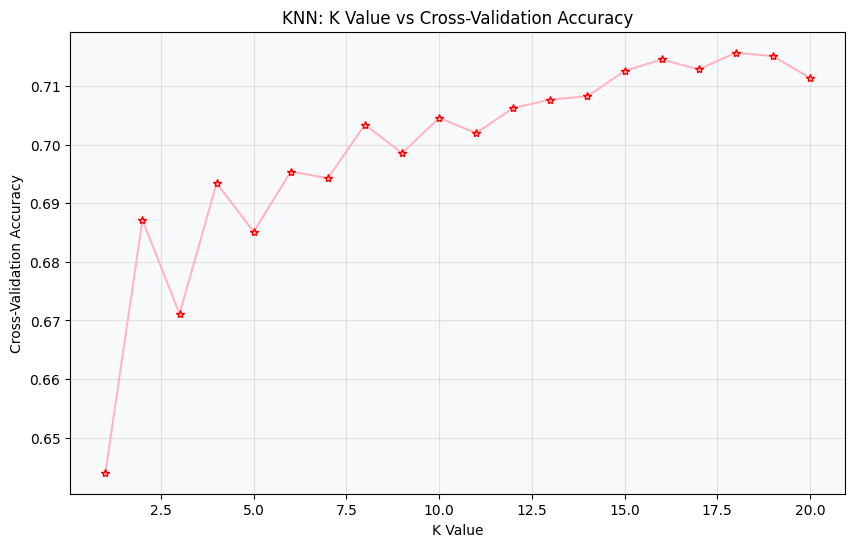

Best K value: 18
Best CV accuracy: 0.7157


In [ ]:
# Find optimal k value using cross-validation
k_values = range(1, 21)
cv_scores = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X_train_scaled, y_train, cv=5, scoring='accuracy')
    cv_scores.append(scores.mean())

    # Plot k vs accuracy
plt.figure(figsize=(10, 6))
plt.plot(k_values, cv_scores, marker='*', color="#ffb6c1", markeredgecolor="red")
plt.title('KNN: K Value vs Cross-Validation Accuracy')
plt.xlabel('K Value')
plt.ylabel('Cross-Validation Accuracy')
plt.grid(True, alpha=0.3)
plt.show()

# Find best k
best_k = k_values[np.argmax(cv_scores)]
print(f"Best K value: {best_k}")
print(f"Best CV accuracy: {max(cv_scores):.4f}")

This code tests different K-value for the KNN model using 5 fold cross validation to find the optimal number of neighbors. Then, the accuracy for each K was plotted to better visualize performance. The KNN model performs best when using 18 neighrbors to make predictions. The cross-validation score of 0.7157 indicates that the model correctly classifies about 71.57% of cases on unseen data, suggesting moderate to good predicitive performance.

In [ ]:
# Train KNN with best k
knn_model = KNeighborsClassifier(n_neighbors=best_k)
knn_model.fit(X_train_scaled, y_train)

# Make predictions
y_pred_knn = knn_model.predict(X_test_scaled)
y_pred_proba_knn = knn_model.predict_proba(X_test_scaled)[:, 1]

# Evaluate the model
print(f"KNN Results (k={best_k}):")
print(f"Accuracy: {accuracy_score(y_test, y_pred_knn):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_knn):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_knn):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_knn):.4f}")
print(f"AUC-ROC: {roc_auc_score(y_test, y_pred_proba_knn):.4f}")

KNN Results (k=18):
Accuracy: 0.7047
Precision: 0.5874
Recall: 0.2718
F1-Score: 0.3716
AUC-ROC: 0.7157


Using the optimal K that was found earlier, this code trains a KNN model to make predictions on the test data. The model is then evaluated using the same metrics used previously.

These results show that while the KNN model achieves moderate overall accuracy (70.47%) and a decent AUC (0.7157), its ability to identify the target class is weak. The low recall (27.18%) and F1-score (0.3716) indicate the model is missing many actual positive cases, likely due to class imbalance. Overall, the model is better at general classification than effectively detecting the minority class, limiting its usefulness for tasks like churn prediction.

**Support Vector Machine (RBF kernal):**

In [ ]:
# Train SVM with different kernels
kernels = ['linear', 'rbf', 'poly']
svm_results = {}

for kernel in kernels:
    print(f"\nTraining SVM with {kernel} kernel...")
    svm_model = SVC(kernel=kernel, random_state=42, probability=True)
    svm_model.fit(X_train_scaled, y_train)

    y_pred_svm = svm_model.predict(X_test_scaled)
    y_pred_proba_svm = svm_model.predict_proba(X_test_scaled)[:, 1]

    accuracy = accuracy_score(y_test, y_pred_svm)
    precision = precision_score(y_test, y_pred_svm)
    recall = recall_score(y_test, y_pred_svm)
    f1 = f1_score(y_test, y_pred_svm)
    auc = roc_auc_score(y_test, y_pred_proba_svm)

    svm_results[kernel] = {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'auc': auc,
        'predictions': y_pred_svm,
        'probabilities': y_pred_proba_svm
    }

    print(f"Accuracy: {accuracy:.4f}")
    print(f"F1-Score: {f1:.4f}")
    print(f"AUC-ROC: {auc:.4f}")

# Find best kernel
best_kernel = max(svm_results.keys(), key=lambda k: svm_results[k]['f1'])
print(f"\nBest kernel: {best_kernel}")


Training SVM with linear kernel...
Accuracy: 0.7280
F1-Score: 0.4835
AUC-ROC: 0.7678

Training SVM with rbf kernel...
Accuracy: 0.7260
F1-Score: 0.4843
AUC-ROC: 0.7584

Training SVM with poly kernel...
Accuracy: 0.7247
F1-Score: 0.4671
AUC-ROC: 0.7391

Best kernel: rbf


This code trains SVM models using different kernels to compare their performance. Kernels in SVM determine how the model separates the data by transforming it into different feature spaces. A linear kernel creates a straight decision boundary, while RBF and polynomial kernels allow for more complex, non-linear relationships. Each model is evaluated using metrics like Accuracy, F1-score, and AUC-ROC, and the best kernel is selected based on the highest F1-score.

These results show that all three SVM kernels perform similarly in accuracy, but the RBF kernel slightly outperforms the others in F1-score, making it the best choice for balancing precision and recall. The linear kernel has the highest AUC, indicating slightly better overall ranking ability, while the polynomial kernel performs the weakest across metrics. Overall, the RBF kernel is selected because it provides the best trade-off for identifying both classes effectively.

In [ ]:
# Hyperparameter tuning for the best kernel
if best_kernel == 'rbf':
    param_grid = {
        'C': [0.1, 1, 10, 100],
        'gamma': ['scale', 'auto', 0.001, 0.01, 0.1, 1]
    }
elif best_kernel == 'linear':
    param_grid = {
        'C': [0.1, 1, 10, 100]
    }
else:  # poly
    param_grid = {
        'C': [0.1, 1, 10],
        'degree': [2, 3, 4]
    }

print(f"Tuning hyperparameters for {best_kernel} kernel...")
svm_grid = SVC(kernel=best_kernel, random_state=42, probability=True)
grid_search = GridSearchCV(svm_grid, param_grid, cv=5, scoring='f1')
grid_search.fit(X_train_scaled, y_train)

print(f"Best parameters: {grid_search.best_params_}")
print(f"Best CV F1-score: {grid_search.best_score_:.4f}")

# Evaluate best model
best_svm = grid_search.best_estimator_
y_pred_svm = best_svm.predict(X_test_scaled)
y_pred_proba_svm = best_svm.predict_proba(X_test_scaled)[:, 1]

print(f"\nBest SVM Test Results:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_svm):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_svm):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_svm):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_svm):.4f}")
print(f"AUC-ROC: {roc_auc_score(y_test, y_pred_proba_svm):.4f}")

Tuning hyperparameters for rbf kernel...
Best parameters: {'C': 100, 'gamma': 0.01}
Best CV F1-score: 0.5383

Best SVM Test Results:
Accuracy: 0.7193
Precision: 0.5805
Recall: 0.4564
F1-Score: 0.5110
AUC-ROC: 0.7501


This code performs hyperparameter tuning to find the best kernel using GridSearchCV to find the optimal settings. It selects the combination that maximizes the F1-score using cross-validation, then evaluates the best model on the test data using standard performance metrics.

On the test set, the model achieves a more balanced performance, with a higher recall (45.64%) and F1-score (0.5110), indicating better detection of positive cases compared to earlier results. Overall, the tuned SVM provides a stronger trade-off between precision and recall, making it more useful for identifying at-risk customers.

**Decision Tree:**

In [ ]:
# Train Decision Tree
dt_model = DecisionTreeClassifier(random_state=42, max_depth=5)
dt_model.fit(X_train, y_train)  # Note: No scaling needed for decision trees

# Make predictions
y_pred_dt = dt_model.predict(X_test)
y_pred_proba_dt = dt_model.predict_proba(X_test)[:, 1]

# Evaluate the model
print("Decision Tree Results:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_dt):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_dt):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_dt):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_dt):.4f}")
print(f"AUC-ROC: {roc_auc_score(y_test, y_pred_proba_dt):.4f}")

Decision Tree Results:
Accuracy: 0.7353
Precision: 0.6098
Recall: 0.4896
F1-Score: 0.5432
AUC-ROC: 0.7821


This code first trains the model using the scaled data and then predictions are made on the test set. To evaluate the model; accuracy, precision, recall, F!-score and AUC-ROC were used to assess overall performance.

These results indicate that the Decision Tree performs well overall, with solid accuracy (73.53%) and the strongest F1-score (0.5432) so far, suggesting a good balance between precision and recall. The recall of 48.96% shows it captures nearly half of the positive cases, making it more effective than several prior models at identifying the target class. Additionally, the highest AUC (0.7821) suggests strong overall classification ability across different thresholds.

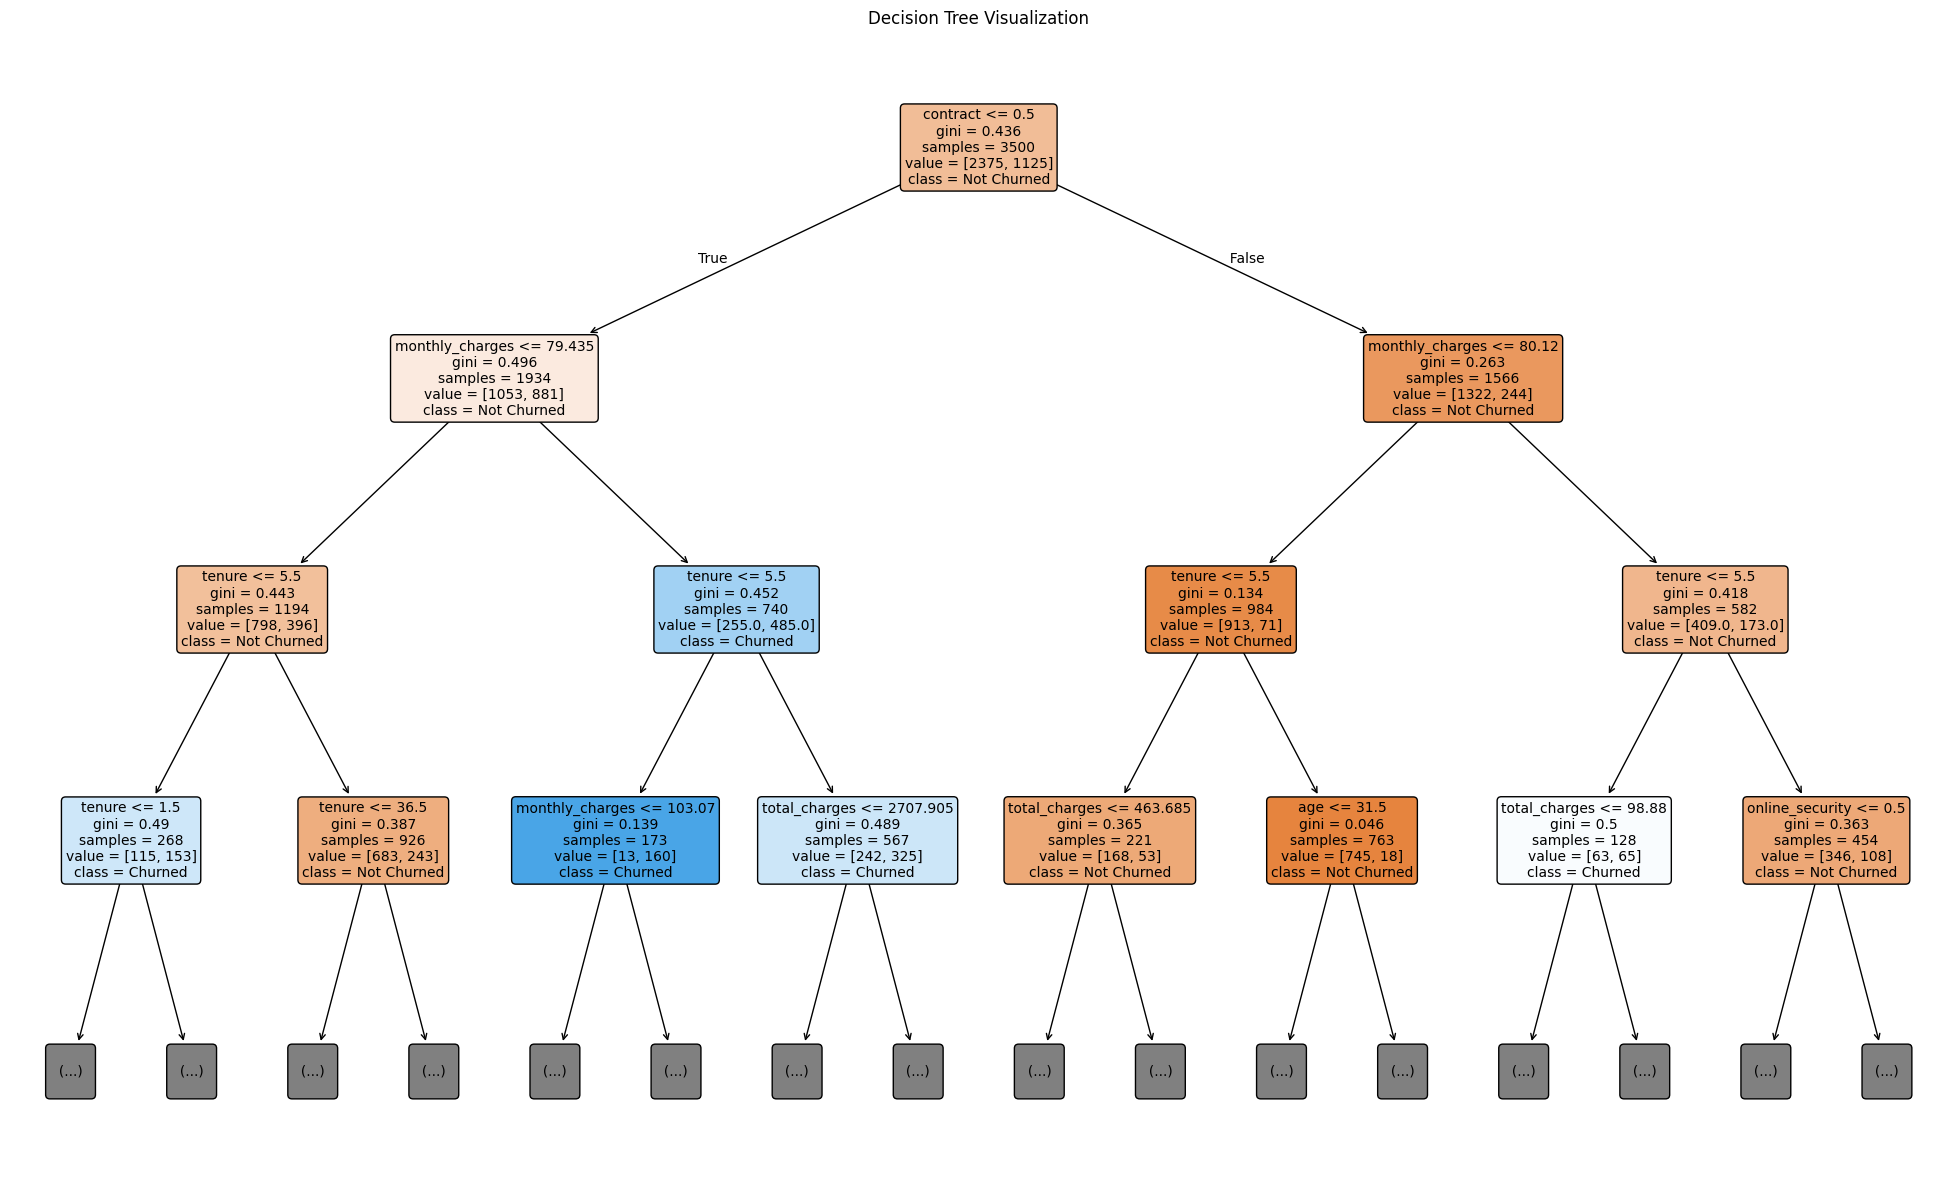

In [ ]:
# Visualize the decision tree
plt.figure(figsize=(25, 15))
plot_tree(dt_model,
          feature_names=X.columns,
          class_names=['Not Churned', 'Churned'],
          filled=True,
          rounded=True,
          fontsize=10,
          max_depth=3)
plt.title('Decision Tree Visualization')
plt.show()

The results of the decison tree are visualized to make it clearer to underrstand. The tree splits data into branches based on key features to make predictions, making it helpful because it’s easy to interpret and clearly shows the most important decision factors which are at the top then split into more specific factors.

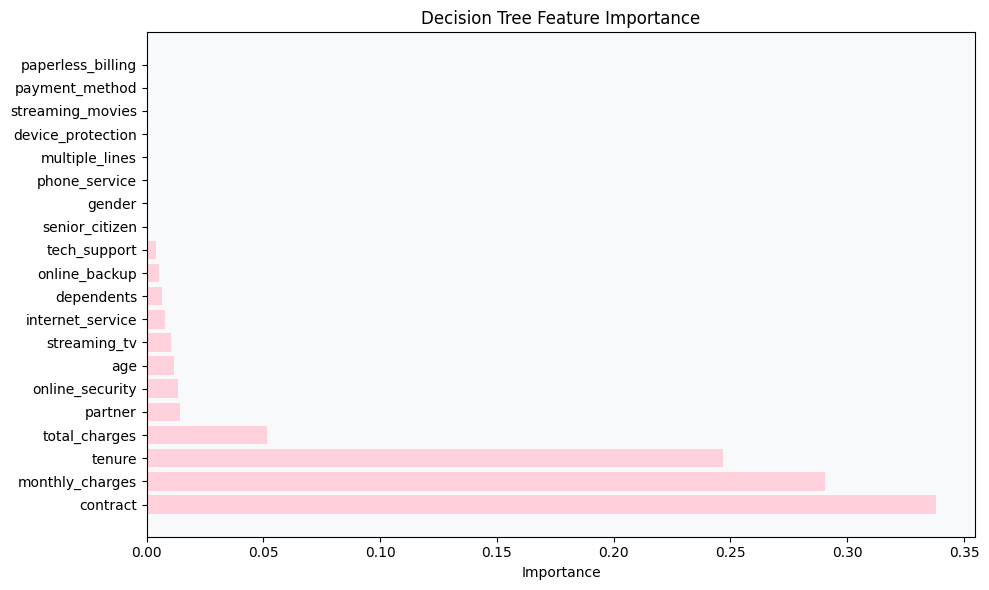

Feature Importance:
              Feature  Importance
15           contract    0.338032
18    monthly_charges    0.290426
0              tenure    0.246953
19      total_charges    0.051701
4             partner    0.014431
9     online_security    0.013316
1                 age    0.011577
13       streaming_tv    0.010440
8    internet_service    0.007707
5          dependents    0.006437
10      online_backup    0.005167
12       tech_support    0.003811
3      senior_citizen    0.000000
2              gender    0.000000
6       phone_service    0.000000
7      multiple_lines    0.000000
11  device_protection    0.000000
14   streaming_movies    0.000000
17     payment_method    0.000000
16  paperless_billing    0.000000


In [ ]:
# Feature importance in decision tree
feature_importance_dt = pd.DataFrame({
    'Feature': features,
    'Importance': dt_model.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(feature_importance_dt['Feature'], feature_importance_dt['Importance'], color="#ffd1dc")
plt.title('Decision Tree Feature Importance')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

print("Feature Importance:")
print(feature_importance_dt)

This is another visualization of the heaviest weighted factors in the decision tree model.

# **Part C: Business Analysis**

Evaluating all models against eachother:

In [ ]:
# Collect all model predictions
models = {
    'Logistic Regression': (y_pred_lr, y_pred_proba_lr),
    'KNN': (y_pred_knn, y_pred_proba_knn),
    'SVM': (y_pred_svm, y_pred_proba_svm),
    'Decision Tree': (y_pred_dt, y_pred_proba_dt)
}

# Create comparison dataframe
comparison_results = []

for model_name, (y_pred, y_pred_proba) in models.items():
    results = {
        'Model': model_name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred),
        'AUC-ROC': roc_auc_score(y_test, y_pred_proba)
    }
    comparison_results.append(results)

comparison_df = pd.DataFrame(comparison_results)
print("Model Comparison:")
print(comparison_df.round(4))

Model Comparison:
                 Model  Accuracy  Precision  Recall  F1-Score  AUC-ROC
0  Logistic Regression    0.7313     0.6138  0.4419    0.5139   0.7707
1                  KNN    0.7047     0.5874  0.2718    0.3716   0.7157
2                  SVM    0.7193     0.5805  0.4564    0.5110   0.7501
3        Decision Tree    0.7353     0.6098  0.4896    0.5432   0.7821


In [ ]:
print("LR predicted churn count:", sum(y_pred_lr))
print("KNN predicted churn count:", sum(y_pred_knn))
print("SVM predicted churn count:", sum(y_pred_svm))
print("DT predicted churn count:", sum(y_pred_dt))

print(" Overall Performance Ranking (by F1-Score):")
ranked_models = comparison_df.sort_values('F1-Score', ascending=False)
print(ranked_models[['Model', 'F1-Score']])

best_model = comparison_df.loc[comparison_df['F1-Score'].idxmax()]
print(best_model)

LR predicted churn count: 347
KNN predicted churn count: 223
SVM predicted churn count: 379
DT predicted churn count: 387
 Overall Performance Ranking (by F1-Score):
                 Model  F1-Score
3        Decision Tree  0.543153
0  Logistic Regression  0.513872
2                  SVM  0.511034
1                  KNN  0.371631
Model        Decision Tree
Accuracy          0.735333
Precision         0.609819
Recall            0.489627
F1-Score          0.543153
AUC-ROC            0.78208
Name: 3, dtype: object


This code compares model performance by printing the number of predicted churn cases for each model and ranking them based on F1-score. It sorts the models to identify the best performer and then displays the full evaluation metrics for the top model.

The results show that the Decision Tree performed best, with the highest F1-score, which indicates the strongest balance between precision and recall. It also predicted the highest number of churn cases, suggesting it is more aggressive in identifying at-risk customers.

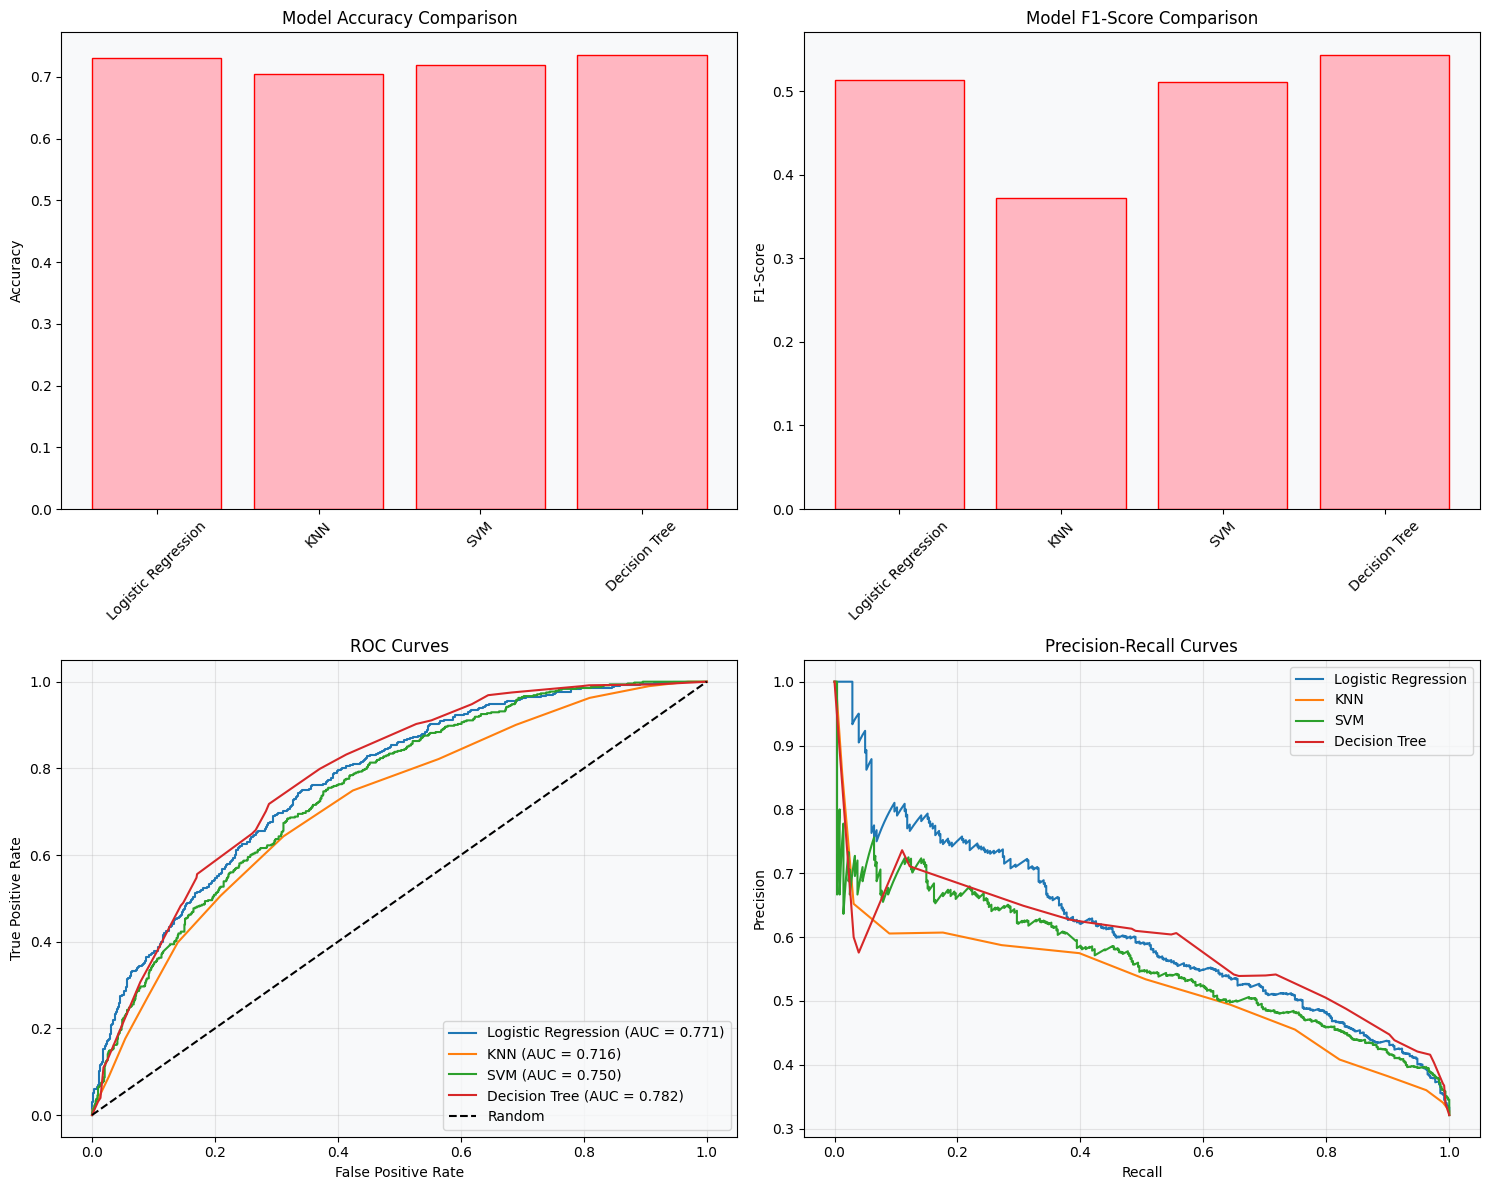

In [ ]:
# Visualize model comparison
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Accuracy comparison
axes[0, 0].bar(comparison_df['Model'], comparison_df['Accuracy'], color='#ffb6c1', edgecolor='red')
axes[0, 0].set_title('Model Accuracy Comparison')
axes[0, 0].set_ylabel('Accuracy')
axes[0, 0].tick_params(axis='x', rotation=45)


# F1-Score comparison
axes[0, 1].bar(comparison_df['Model'], comparison_df['F1-Score'], color='#ffb6c1', edgecolor='red')
axes[0, 1].set_title('Model F1-Score Comparison')
axes[0, 1].set_ylabel('F1-Score')
axes[0, 1].tick_params(axis='x', rotation=45)

# ROC Curves
for model_name, (y_pred, y_pred_proba) in models.items():
    fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
    auc = roc_auc_score(y_test, y_pred_proba)
    axes[1, 0].plot(fpr, tpr, label=f'{model_name} (AUC = {auc:.3f})')

axes[1, 0].plot([0, 1], [0, 1], 'k--', label='Random')
axes[1, 0].set_xlabel('False Positive Rate')
axes[1, 0].set_ylabel('True Positive Rate')
axes[1, 0].set_title('ROC Curves')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Precision-Recall Curves
for model_name, (y_pred, y_pred_proba) in models.items():
    precision, recall, _ = precision_recall_curve(y_test, y_pred_proba)
    axes[1, 1].plot(recall, precision, label=model_name)

axes[1, 1].set_xlabel('Recall')
axes[1, 1].set_ylabel('Precision')
axes[1, 1].set_title('Precision-Recall Curves')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

The above is a visualization of how each model performaned against each other using the same metrics.

In [ ]:
print("Top 3 Important Features:")
top_features = feature_importance.head(3)
print(top_features)





Top 3 Important Features:
             Feature  Coefficient  Abs_Coefficient
0             tenure    -0.919752         0.919752
15          contract    -0.867225         0.867225
8   internet_service     0.515677         0.515677


# Best Model based on F1-Score:

The best model based on F1-score is the decision tree. It had the highest F1-score of roughly 54%, indicating that it had a moderate balance between precision and recall. In context of predicting churn, this model provides the best trade off between correctly identifying customers who are likely to leave while minimizing incorrect classifications.

# Top Three Important Features:

The top three important features when predicting churn is tenure, contract type and internet service. These variables had the highest impact on whether a customer is likely to leave or stay.

# Recommendations to reduce Churn:

1. Customers on month-to-month contracts tend to have significantly higher churn rates. The company shoud offer targeted intiatives to those customers to incentivize them to switch to a longer term contract.

2. Customers who do not subscribe to additional services are more likely to churn. The company should promote specials such as free trials, bundle pricing etc. on these services to those customers.